In [1]:
#import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
# Spatial subsetting of netcdf files


In [17]:
df=xr.open_dataset("/home/hpcs_rnd/Yatendra_IITKgp/data/IMDAA_daily_data_1991_2020.nc")
df

<xarray.Dataset> Size: 186MB
Dimensions:   (latitude: 32, longitude: 32, time: 11323)
Coordinates:
    lat       (latitude) float64 256B ...
    lon       (longitude) float64 256B ...
  * time      (time) datetime64[ns] 91kB 1990-01-01 1990-01-02 ... 2020-12-31
Dimensions without coordinates: latitude, longitude
Data variables:
    HGT_prl   (time, latitude, longitude) float32 46MB ...
    TMP_prl   (time, latitude, longitude) float32 46MB ...
    TMP_2m    (time, latitude, longitude) float32 46MB ...
    APCP_sfc  (time, latitude, longitude) float32 46MB ...
Attributes:
    CDI:                  Climate Data Interface version 1.9.8 (https://mpime...
    Conventions:          COARDS
    history:              Wed Jun 14 21:34:08 2023: cdo -f nc4c -z zip_4 copy...
    History:              created by wgrib2
    GRIB2_grid_template:  0
    CDO:                  Climate Data Operators version 1.9.8 (https://mpime...
    regrid_method:        bilinear

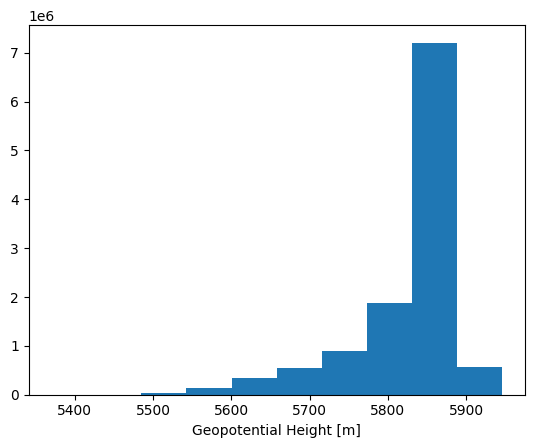

In [3]:
dx=df['HGT_prl']
dx.plot()
plt.show()

In [6]:
dt= dx.groupby('time.year').max(skipna=True)
dt

<xarray.DataArray 'HGT_prl' (year: 31, latitude: 32, longitude: 32)> Size: 127kB
array([[[5892.0664, 5892.335 , 5892.495 , ..., 5894.495 , 5896.62  ,
         5896.995 ],
        [5893.085 , 5893.0225, 5892.87  , ..., 5894.87  , 5895.37  ,
         5896.62  ],
        [5894.0664, 5893.245 , 5893.12  , ..., 5895.245 , 5895.12  ,
         5895.37  ],
        ...,
        [5921.2065, 5917.0815, 5911.769 , ..., 5892.8613, 5889.696 ,
         5886.071 ],
        [5923.894 , 5920.3315, 5915.7065, ..., 5887.6113, 5880.7363,
         5877.04  ],
        [5925.5815, 5922.4565, 5919.96  , ..., 5880.424 , 5877.915 ,
         5875.4775]],

       [[5892.799 , 5892.7363, 5892.6113, ..., 5889.2085, 5890.021 ,
         5889.771 ],
        [5893.4863, 5893.424 , 5893.924 , ..., 5889.8335, 5890.0835,
         5890.4585],
        [5892.9863, 5892.9497, 5892.9863, ..., 5889.7085, 5890.021 ,
         5890.7783],
...
        [5924.462 , 5923.919 , 5924.044 , ..., 5906.7295, 5905.7295,
         5904.4795],
        [5928.7744, 5923.1494, 5918.212 , ..., 5903.792 , 5901.2295,
         5899.792 ],
        [5930.5244, 5924.1494, 5918.962 , ..., 5899.917 , 5896.9795,
         5892.417 ]],

       [[5906.6064, 5905.9814, 5906.4775, ..., 5905.54  , 5906.7275,
         5905.9775],
        [5906.794 , 5906.794 , 5906.9775, ..., 5906.415 , 5906.7275,
         5906.9775],
        [5907.294 , 5907.4814, 5907.4775, ..., 5906.915 , 5907.3525,
         5907.2275],
        ...,
        [5905.3535, 5905.541 , 5905.791 , ..., 5907.291 , 5903.916 ,
         5899.2285],
        [5893.166 , 5894.041 , 5895.9785, ..., 5901.291 , 5897.1035,
         5891.7285],
        [5880.9785, 5883.916 , 5885.916 , ..., 5892.291 , 5886.2285,
         5880.6035]]], dtype=float32)
Coordinates:
    lat      (latitude) float64 256B ...
    lon      (longitude) float64 256B ...
  * year     (year) int64 248B 1990 1991 1992 1993 1994 ... 2017 2018 2019 2020
Dimensions without coordinates: latitude, longitude
Attributes:
    long_name:   Geopotential Height
    units:       m
    short_name:  HGT
    level:       pressure level

In [21]:
dl = dt.groupby("year").max(["latitude", "longitude"])


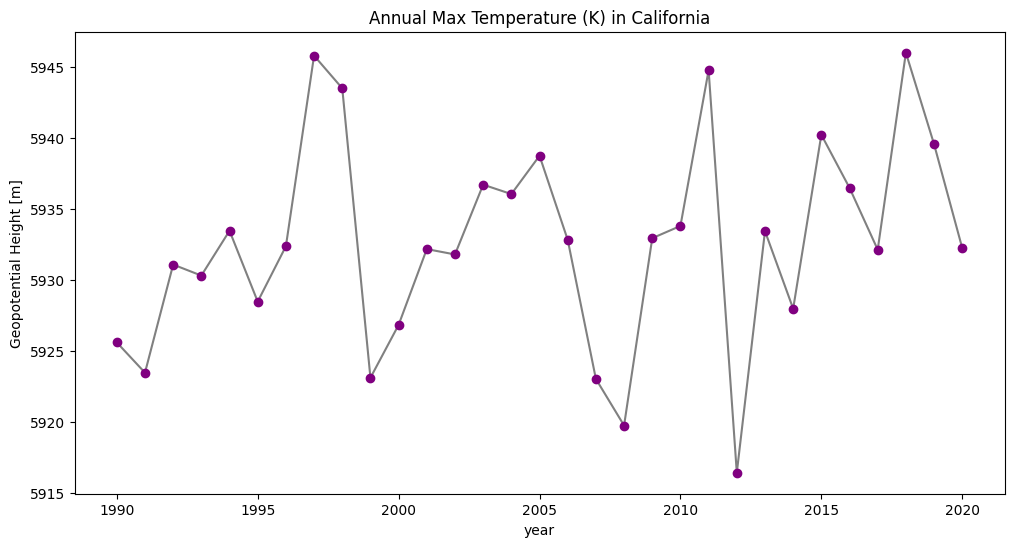

In [22]:
f, ax = plt.subplots(figsize=(12, 6))
dl.plot.line(hue='lat',
             marker="o",
             ax=ax,
             color="grey",
             markerfacecolor="purple",
             markeredgecolor="purple")
ax.set(title="Annual Max Temperature (K) in California")
plt.show()

In [20]:
df=xr.open_dataset(r"/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/GPCP_JJAS_1981-2010.nc",decode_times=False)
dg=xr.open_dataset(r'/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/JJASavg_IMDgrid_CFSrain_ens-wise.nc',decode_times=False)

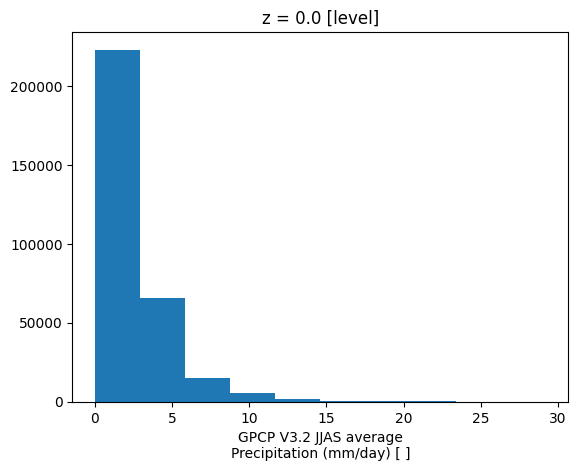

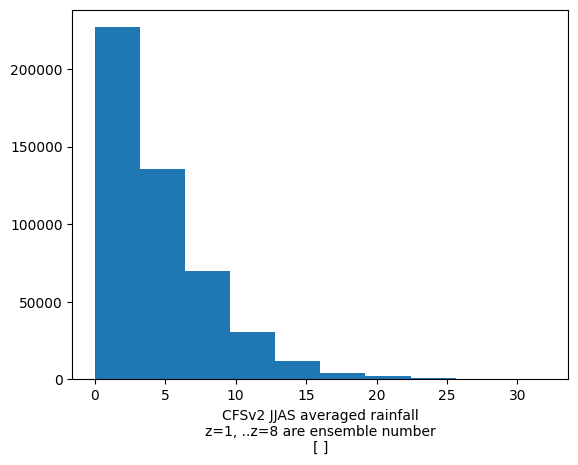

In [21]:
dx=df['pr']
dx.plot()
plt.show()
dx1=dg['cfs']
dx1.plot()
plt.show()

In [14]:
dx1 = dx1.groupby("time").max(["latitude", "longitude"])

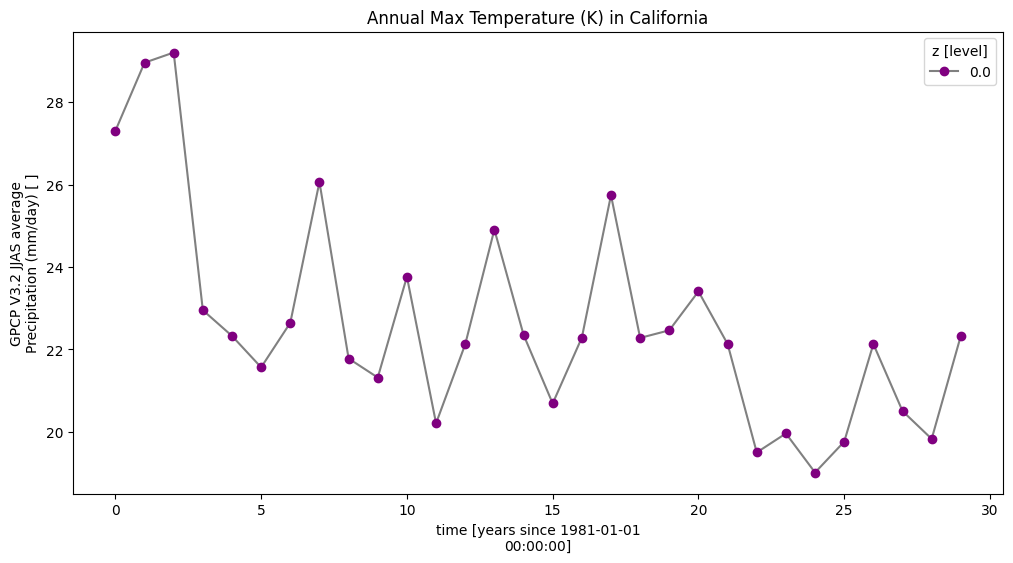

ValueError: Unrecognized marker style 'z'

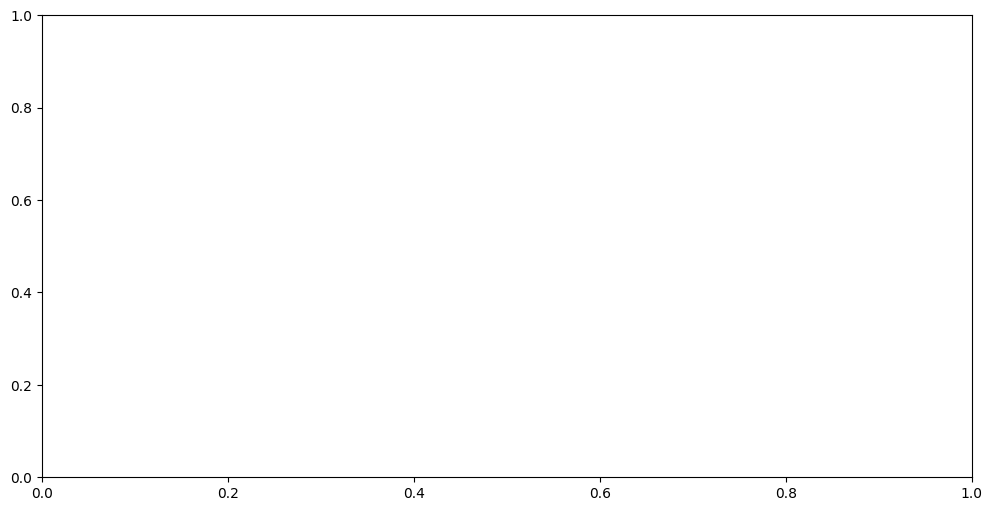

In [19]:
f, ax = plt.subplots(figsize=(12, 6))
dx.plot.line(hue='z',
             marker="o",
             ax=ax,
             color="grey",
             markerfacecolor="purple",
             markeredgecolor="purple")
ax.set(title="Annual Max Temperature (K) in California")
plt.show()
f, ax = plt.subplots(figsize=(12, 6))
dx1.plot.line(hue='time',
             marker="z",
             ax=ax,
             color="grey",
             markerfacecolor="purple",
             markeredgecolor="purple")
ax.set(title="Annual Max Temperature (K) in California")
plt.show()